# F1 — Circuits (1950–2024)

Circuit-level analyses across the full history of F1.
This notebook covers **Section 7** of `QuestionsF1.txt`.

## Questions covered
| # | Question |
|---|---|
| 7.1  | How many host cities does each country have? *(top 10)* |
| 7.2  | Average laps per race, by circuit *(top 5 high / low, 1990+)* |
| 7.3  | One-shot circuits — every venue that hosted exactly 1 race |
| 7.4  | Top 10 circuits — most races hosted (most popular) |
| 7.5  | Top 10 most dangerous circuits — by avg incidents per race |
| 7.6  | Top 10 circuits — pole→P1 and pole→P2 conversion *(1990+)* |
| 7.7  | Circuits with most & fewest overtakes per race *(1996+, cleaned)* |
| 7.8  | Races with the most lead changes *(1996+, lap data)* |
| 7.9  | Median race finish time per circuit |
| 7.10 | Most successful circuit per driver (top 10 winners) |


## Setup — imports, data loading, Indy cleanup


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from f1_utils import (
    show_and_save, eras_df, year_to_era, apply_default_style,
)
apply_default_style()

sns.set_theme(style='whitegrid')

drivers      = pd.read_csv('excel/drivers.csv')
results      = pd.read_csv('excel/results.csv')
races        = pd.read_csv('excel/races.csv')
constructors = pd.read_csv('excel/constructors.csv')
circuits     = pd.read_csv('excel/circuits.csv')
status       = pd.read_csv('excel/status.csv')

drivers['driver'] = drivers['surname'] + ' ' + drivers['forename'].str[0] + '.'

# Indy cleanup — strip the 1950–60 oval race rows
indy_race_ids = races.loc[
    races['name'].str.contains('Indianapolis', case=False, na=False), 'raceId']
results = results[~results['raceId'].isin(indy_race_ids)].copy()
races   = races  [~races  ['raceId'].isin(indy_race_ids)].copy()

os.makedirs('charts', exist_ok=True)

def show_and_save(filename, dpi=150):
    plt.savefig(f'charts/{filename}', dpi=dpi, bbox_inches='tight')
    plt.show()


DECADE_COLORS = {
    1950: '#8B2635', 1960: '#D2691E', 1970: '#DAA520', 1980: '#2E8B57',
    1990: '#0E7C7B', 2000: '#1F4E79', 2010: '#5B2A86', 2020: '#3A3A3A',
}

# Compact circuit label — 'Spa', 'Monaco', etc. Used everywhere.
circuits['circuit'] = circuits['name'].str.replace(' Circuit', '', regex=False)

# Race × circuit join — used by every question
race_full = races.merge(circuits[['circuitId', 'circuit', 'country']], on='circuitId')

print(f'Circuits in dataset : {len(circuits)}')
print(f'Races in dataset    : {len(races):,}')
print(f'Years covered       : {races["year"].min()}–{races["year"].max()}')


Circuits in dataset : 77
Races in dataset    : 1,114
Years covered       : 1950–2024


---
### Chart 7.1 — How many host cities does each country have? *(top 10)*

`circuits.location` holds the host city for each venue. Group by country and count distinct cities — answers "which countries spread F1 across the most local hosts vs concentrate it in one place?".

**Note on the printed table:** when Jupyter shows `Output is truncated. View as a scrollable element` it just means the printed lines exceeded the notebook's default display height — *all* the data is still there, the UI just clipped it. Expand the output cell or open the notebook in a wider editor to see the full table. To keep the chart readable, the per-city year ranges live below in the markdown instead of on the bars:

**Per-city year ranges for the top 10 countries:**

| Country | Cities (with race years) |
|---|---|
| USA | Sebring (1959), Riverside (1960), Watkins Glen (1961–1980), Long Beach (1976–1983), Las Vegas (1981–1982, 2023–), Dallas (1984), Detroit (1982–1988), Phoenix (1989–1991), Indianapolis (2000–2007), Austin (2012–), Miami (2022–) |
| UK | Silverstone (1950–), Aintree/Liverpool (1955–1962), Brands Hatch (1964–1986), Donington (1993) |
| Italy | Monza (1950–), Pescara (1957), Imola (1980–) |
| Germany | Nürburgring (1951–), AVUS Berlin (1959), Hockenheim (1970–) |
| France | Reims (1950–1966), Rouen (1952–1968), Clermont-Ferrand (1965–1972), Le Mans (1967), Dijon (1974–1984), Magny-Cours (1991–2008), Paul Ricard (1971–, intermittent) |
| Japan | Fuji (1976–1977, 2007–2008), Suzuka (1987–) |
| Spain | Pedralbes/Barcelona-suburb (1951–1954), Jarama/Madrid (1968–1981), Jerez (1986–1997), Catalunya (1991–), Valencia (2008–2012) |
| Belgium | Spa-Francorchamps (1950–), Zolder (1973–1984), Nivelles (1972–1974) |
| Australia | Adelaide (1985–1995), Melbourne (1996–) |
| Sweden | Anderstorp — the only F1 host in Sweden, 1973–1978 |

7.1 — Top 10 countries by distinct host cities:
 country  cities  total_races
     USA      10           66
  France       7           63
   Spain       5           61
      UK       4           79
Portugal       4           18
   Italy       4          107
  Canada       3           53
   Japan       3           40
 Germany       3           79
 Belgium       3           69


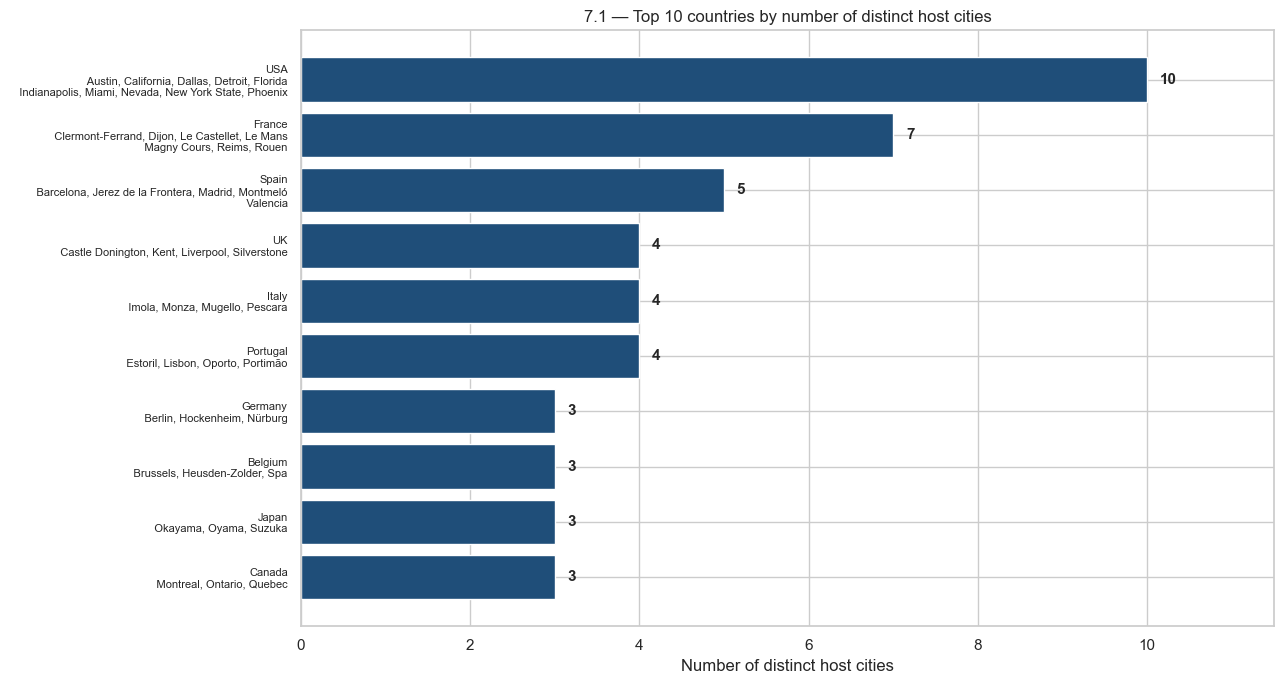

In [72]:
# City-level year range — kept only as the intermediate dataframe used to roll
# up to the country level. The per-city detail lives in the markdown lookup
# table above the cell, so we don't print this 70-row dataframe to the output.
city_years = (race_full.merge(circuits[['circuitId', 'location']], on='circuitId')
              .groupby(['country', 'location'])
              .agg(first_year=('year', 'min'),
                   last_year=('year', 'max'),
                   races=('raceId', 'count'))
              .reset_index()
              .sort_values(['country', 'first_year']))

# Country-level summary
country_summary = (city_years.groupby('country')
                   .agg(cities=('location', 'nunique'),
                        total_races=('races', 'sum'),
                        city_names=('location', lambda s: ', '.join(sorted(s.unique()))))
                   .reset_index()
                   .sort_values('cities', ascending=False))

top10_cities = country_summary.head(10)

print('7.1 — Top 10 countries by distinct host cities:')
print(top10_cities[['country', 'cities', 'total_races']].to_string(index=False))


# Chart — tight x-axis cap; just the count next to the bar, city names go BELOW the bar
plot_df = top10_cities.sort_values('cities')
max_cities = plot_df['cities'].max()
fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(range(len(plot_df)), plot_df['cities'],
        color='#1F4E79', edgecolor='white')
ax.set_yticks(range(len(plot_df)))
# Y-tick = "Country (city list)" on two lines — moves the long text out of the plot area
labels = []
for r in plot_df.itertuples():
    # Wrap city list if too long — split into max ~50-char chunks at comma boundaries
    cl = r.city_names
    if len(cl) > 55:
        parts, current = [], ''
        for piece in cl.split(', '):
            if len(current) + len(piece) + 2 > 55:
                parts.append(current.rstrip(', '))
                current = piece + ', '
            else:
                current += piece + ', '
        parts.append(current.rstrip(', '))
        cl = '\n   '.join(parts)
    labels.append(f'{r.country}\n   {cl}')
ax.set_yticklabels(labels, fontsize=8)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.cities + 0.15, i, f'{int(row.cities)}',
            va='center', fontsize=11, fontweight='bold')

ax.set_title('7.1 — Top 10 countries by number of distinct host cities')
ax.set_xlabel('Number of distinct host cities')
ax.set_xlim(0, max_cities + 1.5)
plt.tight_layout()
show_and_save('7.1_cities_per_country.png')


---
### Chart 7.2 — Average laps per race, by circuit *(top 5 high, top 5 low, 1990+)*

The previous version of this chart picked the single highest/lowest lap-count races, which surfaced 1960s historical layouts and weather-shortened "ghost" races (Belgium 2021 at 1 lap, Nürburgring Nordschleife at 14 laps). **Averaging by circuit** is the cleaner question — *"where do races typically run the most/fewest laps?"* — and naturally smooths over one-off outliers.

Same era filter (1990+, min 5 races per circuit). The AVG is computed across all winner lap-counts at that circuit.

**What to expect:**
- High end: short tracks like Monaco (~78), Hungaroring (~70), where lap times are slow so more laps fit in the 2-hour cap.
- Low end: long-lap tracks like Spa (~44), Suzuka (~53), Baku (~51), where each lap takes ~1.5–2 minutes.


7.2 — Top 5 circuits with HIGHEST avg laps per race (1990+, min 5 races):
                      circuit country  avg_laps  races  first_year  last_year
            Circuit de Monaco  Monaco 76.941176     34        1990       2024
  Indianapolis Motor Speedway     USA 73.000000      8        2000       2007
                  Hungaroring Hungary 72.542857     35        1990       2024
Circuit de Nevers Magny-Cours  France 71.111111     18        1991       2008
                Red Bull Ring Austria 70.900000     20        1997       2024

7.2 — Top 5 circuits with LOWEST avg laps per race (1990+, min 5 races):
                     circuit    country  avg_laps  races  first_year  last_year
Circuit de Spa-Francorchamps    Belgium 42.424242     33        1990       2024
                   Baku City Azerbaijan 51.000000      8        2016       2024
                      Suzuka      Japan 51.677419     31        1990       2024
              Sochi Autodrom     Russia 52.875000      8        

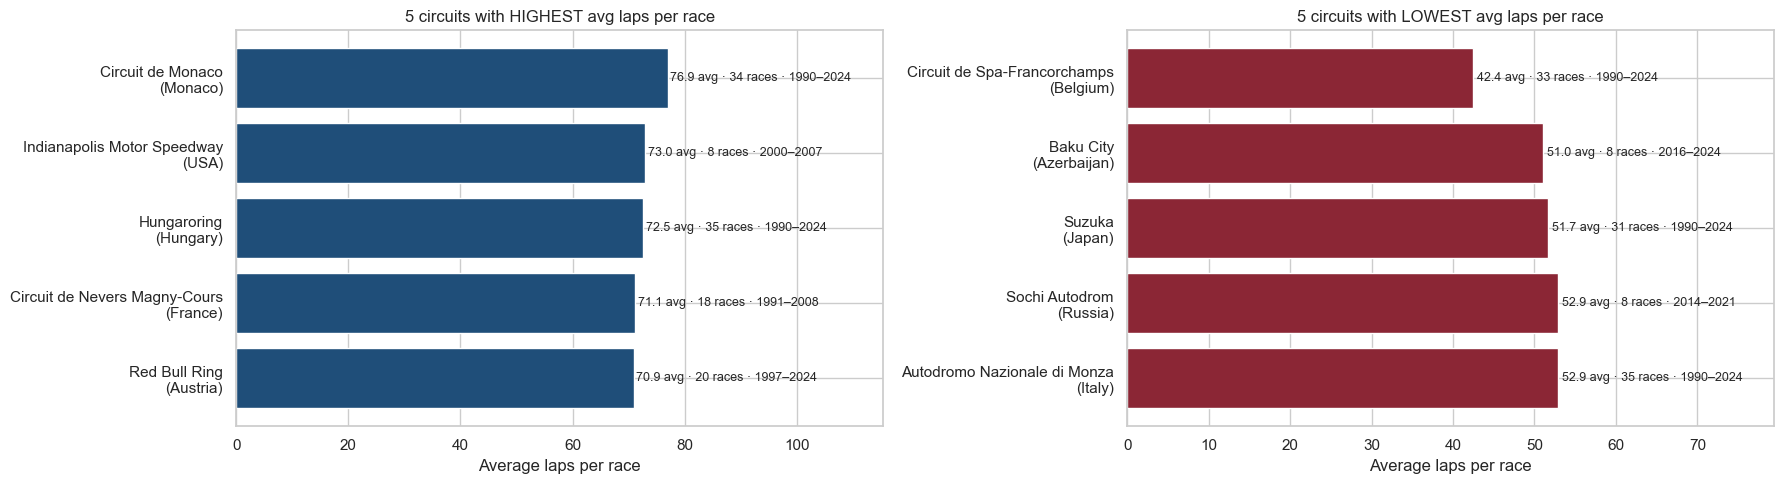

In [73]:
winner_laps = (results[results['positionOrder'] == 1]
               .merge(race_full[['raceId', 'circuit', 'country', 'year']], on='raceId')
               [['year', 'circuit', 'country', 'laps']])

# Modern era only
winner_laps = winner_laps[winner_laps['year'] >= 1990].copy()

per_circuit_laps = (winner_laps.groupby(['circuit', 'country'])
                    .agg(avg_laps=('laps', 'mean'),
                         races=('laps', 'count'),
                         first_year=('year', 'min'),
                         last_year=('year', 'max'))
                    .reset_index())
per_circuit_laps = per_circuit_laps[per_circuit_laps['races'] >= 5]

most_laps   = per_circuit_laps.nlargest(5, 'avg_laps')
fewest_laps = per_circuit_laps.nsmallest(5, 'avg_laps')

print('7.2 — Top 5 circuits with HIGHEST avg laps per race (1990+, min 5 races):')
print(most_laps.to_string(index=False))
print('\n7.2 — Top 5 circuits with LOWEST avg laps per race (1990+, min 5 races):')
print(fewest_laps.to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, df, title, color in [
    (axes[0], most_laps.sort_values('avg_laps'),
     '5 circuits with HIGHEST avg laps per race', '#1F4E79'),
    (axes[1], fewest_laps.sort_values('avg_laps', ascending=False),
     '5 circuits with LOWEST avg laps per race', '#8B2635'),
]:
    ax.barh(range(len(df)), df['avg_laps'], color=color, edgecolor='white')
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([f'{c}\n({k})' for c, k in zip(df['circuit'], df['country'])])
    for i, row in enumerate(df.itertuples()):
        ax.text(row.avg_laps + 0.5, i,
                f'{row.avg_laps:.1f} avg · {int(row.races)} races · '
                f'{int(row.first_year)}–{int(row.last_year)}',
                va='center', fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('Average laps per race')
    ax.set_xlim(0, df['avg_laps'].max() * 1.50)

plt.tight_layout()
show_and_save('7.2_avg_laps_per_circuit.png')


---
### Charts 7.3 & 7.4 — One-shot circuits & most-popular circuits

`COUNT(*) FROM races GROUP BY circuitId`.

- **7.3** — every circuit that hosted **exactly 1 race**. Printed as a reference table only (no chart — bars of length 1 wouldn't add anything visual). Most are 1950s European tracks or COVID-era emergency calendars.
- **7.4** — top 10 most-raced (the F1 cathedrals).


7.3 — One-shot circuits (reference table): 11 venues
                             circuit  country  first_year
                             Pescara    Italy        1957
                            Ain Diab  Morocco        1958
                       Monsanto Park Portugal        1959
       Sebring International Raceway      USA        1959
                                AVUS  Germany        1959
     Riverside International Raceway      USA        1960
                             Zeltweg  Austria        1964
                             Le Mans   France        1967
                           Fair Park      USA        1984
                      Donington Park       UK        1993
Autodromo Internazionale del Mugello    Italy        2020

7.4 — Top 10 most races hosted:
                     circuit country  races  first_year  last_year
Autodromo Nazionale di Monza   Italy     74        1950       2024
           Circuit de Monaco  Monaco     70        1950       2024
                 

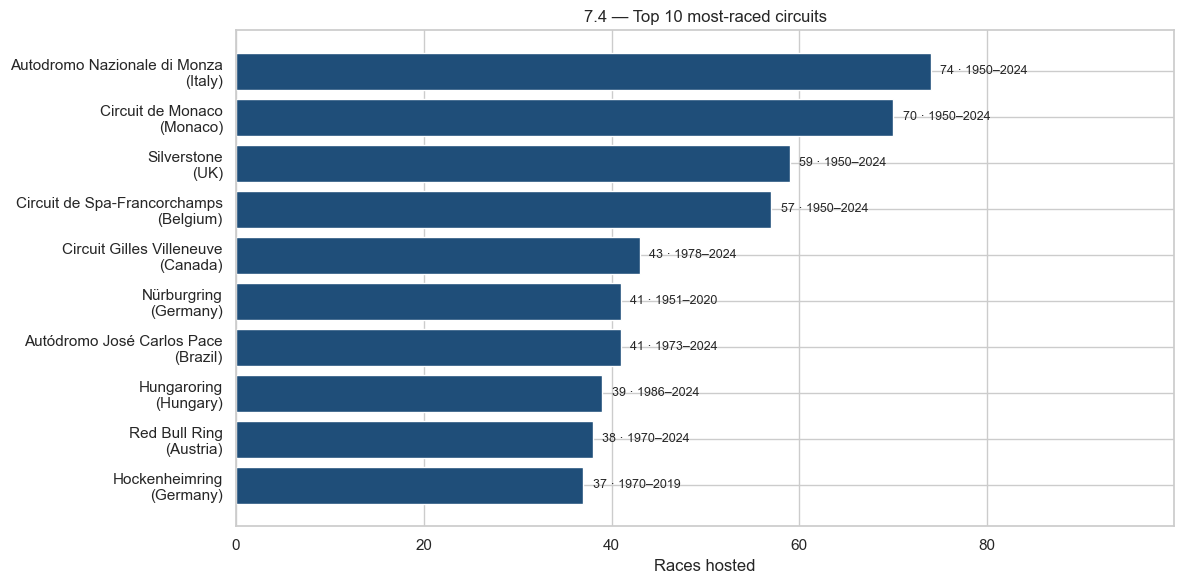

In [74]:
races_per_circuit = (
    race_full.groupby(['circuitId', 'circuit', 'country'])
    .agg(races=('raceId', 'count'),
         first_year=('year', 'min'),
         last_year=('year', 'max'))
    .reset_index()
)

# 7.3 — one-shot circuits printed as a reference table (no chart)
one_shots = (races_per_circuit[races_per_circuit['races'] == 1]
             .sort_values('first_year'))
print(f'7.3 — One-shot circuits (reference table): {len(one_shots)} venues')
print(one_shots[['circuit', 'country', 'first_year']].to_string(index=False))

# 7.4 — top 10 most raced
top10 = races_per_circuit.sort_values('races', ascending=False).head(10)
print(f'\n7.4 — Top 10 most races hosted:')
print(top10[['circuit', 'country', 'races', 'first_year', 'last_year']]
      .to_string(index=False))


# Single chart — 7.4 only (7.3 is table-only)
top = top10.sort_values('races')
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top)), top['races'], color='#1F4E79', edgecolor='white')
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f'{c}\n({k})' for c, k in zip(top['circuit'], top['country'])])
for i, row in enumerate(top.itertuples()):
    ax.text(row.races + 1, i,
            f'{row.races} · {int(row.first_year)}–{int(row.last_year)}',
            va='center', fontsize=9)
ax.set_title('7.4 — Top 10 most-raced circuits')
ax.set_xlim(0, top['races'].max() * 1.35)
ax.set_xlabel('Races hosted')
plt.tight_layout()
show_and_save('7.4_most_popular_circuits.png')


**SQL equivalent**
```sql
-- 7.3: every circuit that hosted exactly 1 race
SELECT c.name AS circuit, c.country, MIN(ra.year) AS year
FROM   races    ra
JOIN   circuits c ON ra.circuitId = c.circuitId
WHERE  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY c.circuitId
HAVING COUNT(*) = 1
ORDER  BY year;

-- 7.4: top 10 most-raced circuits
SELECT c.name AS circuit, c.country,
       COUNT(*) AS races,
       MIN(ra.year) AS first_year, MAX(ra.year) AS last_year
FROM   races    ra
JOIN   circuits c ON ra.circuitId = c.circuitId
WHERE  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY c.circuitId
ORDER  BY races DESC
LIMIT  10;
```


---
### Chart 7.5 — Top 10 most dangerous circuits *(by incidents per race, min 5 races)*

"Dangerous" here = number of results rows where the driver's final `status` indicates a crash or safety-related stoppage. We use the following `statusId` set:

| ID | Status | ID | Status |
|---|---|---|---|
| 3 | Accident | 89 | Safety concerns |
| 4 | Collision | 100 | Driver unwell |
| 78 | Safety | 104 | Fatal accident |
| 82 | Injury | 137 | Damage |

**Why per-race rate, not total count?** Total incidents reward circuits that simply hosted more races — Monza accumulates more crashes than Sochi because it has 74× more chances. The *rate* (incidents ÷ races) controls for that, so the chart answers the real question: *"if you had to race here once, how likely is something to go wrong?"*

Filtered to circuits with **≥5 races**. Each bar carries the **year range** of races held at that circuit, written inside the bar in white text.


Incidents per status (across all circuits):
status
Accident           1015
Collision           854
Injury               13
Driver unwell        10
Fatal accident        3
Safety                2
Safety concerns       2
Damage                2

7.5 — Top 10 most dangerous circuits (by avg incidents per race, min 5 races):
                              circuit   country  incidents  races  first_year  last_year  incidents_per_race
                           Long Beach       USA         42      8        1976       1983            5.250000
                       Detroit Street       USA         28      7        1982       1988            4.000000
                               Zolder   Belgium         39     10        1973       1984            3.900000
                    Circuit de Monaco    Monaco        199     70        1950       2024            2.842857
                      Adelaide Street Australia         31     11        1985       1995            2.818182
          Indianapolis 

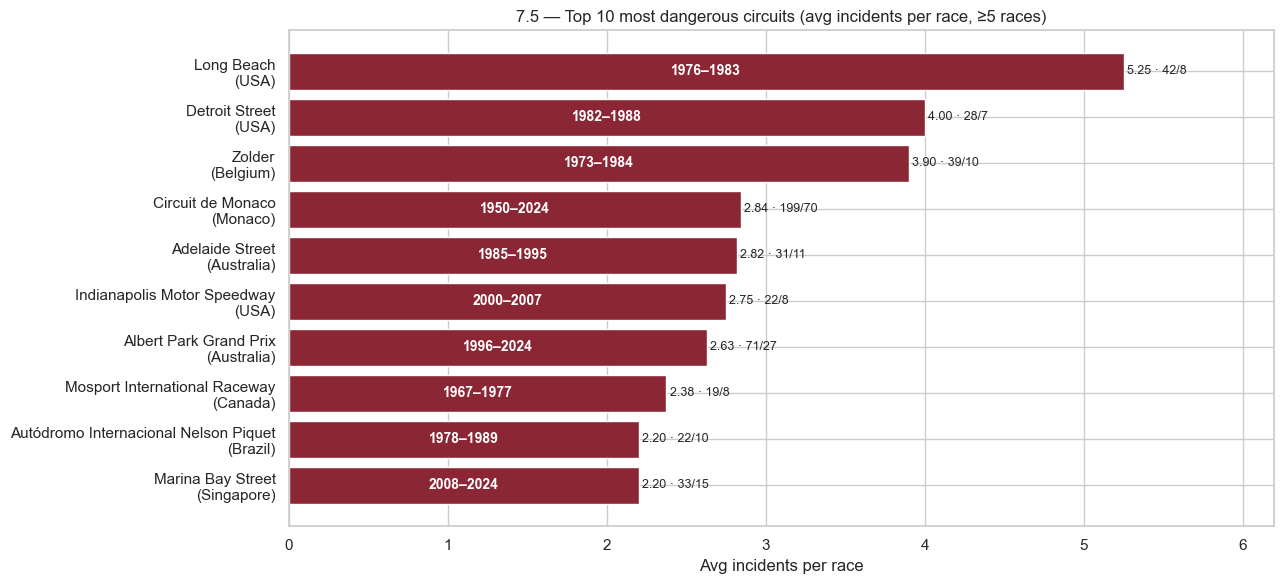

In [75]:
DANGER_STATUS_IDS = [3, 4, 78, 82, 89, 100, 104, 137]

results_full = (results.merge(race_full[['raceId', 'circuitId', 'circuit', 'country', 'year']],
                              on='raceId')
                .merge(status, on='statusId'))

danger = results_full[results_full['statusId'].isin(DANGER_STATUS_IDS)]

incidents_per_circuit = (danger.groupby(['circuit', 'country']).size()
                         .reset_index(name='incidents'))

races_per_circuit_simple = (race_full.groupby(['circuit', 'country'])
                            .agg(races=('raceId', 'nunique'),
                                 first_year=('year', 'min'),
                                 last_year=('year', 'max'))
                            .reset_index())

dangerous = incidents_per_circuit.merge(races_per_circuit_simple, on=['circuit', 'country'])
dangerous['incidents_per_race'] = dangerous['incidents'] / dangerous['races']
dangerous = dangerous[dangerous['races'] >= 5]

print('Incidents per status (across all circuits):')
print(danger['status'].value_counts().to_string())
print()

top_danger = dangerous.sort_values('incidents_per_race', ascending=False).head(10)
print('7.5 — Top 10 most dangerous circuits (by avg incidents per race, min 5 races):')
print(top_danger.to_string(index=False))

# Bar — tight x-axis
plot_df = top_danger.sort_values('incidents_per_race')
max_rate = plot_df['incidents_per_race'].max()

plt.figure(figsize=(13, 6))
plt.barh(range(len(plot_df)), plot_df['incidents_per_race'],
         color='#8B2635', edgecolor='white')
plt.yticks(range(len(plot_df)),
           [f'{c}\n({k})' for c, k in zip(plot_df['circuit'], plot_df['country'])])
for i, row in enumerate(plot_df.itertuples()):
    # End-of-bar: short rate + counts (no "races" word, just numbers)
    plt.text(row.incidents_per_race + 0.02, i,
             f'{row.incidents_per_race:.2f} · {int(row.incidents)}/{int(row.races)}',
             va='center', fontsize=9)
    # Inside bar: year range (white text)
    plt.text(row.incidents_per_race * 0.5, i,
             f'{int(row.first_year)}–{int(row.last_year)}',
             va='center', ha='center', fontsize=10, color='white', fontweight='bold')
plt.title('7.5 — Top 10 most dangerous circuits (avg incidents per race, ≥5 races)')
plt.xlabel('Avg incidents per race')
plt.ylabel('')
plt.xlim(0, max_rate * 1.18)
plt.tight_layout()
show_and_save('7.5_dangerous_circuits.png')


**SQL equivalent**
```sql
-- 7.5: Avg incidents per race, per circuit (≥5 races)
WITH inc AS (
    SELECT ra.circuitId, COUNT(*) AS incidents
    FROM   results r
    JOIN   races   ra ON r.raceId = ra.raceId
    WHERE  r.statusId IN (3, 4, 78, 82, 89, 100, 104, 137)
      AND  ra.name NOT LIKE '%Indianapolis%'
    GROUP  BY ra.circuitId
),
rc AS (
    SELECT circuitId, COUNT(*) AS races
    FROM   races
    WHERE  name NOT LIKE '%Indianapolis%'
    GROUP  BY circuitId
)
SELECT c.name AS circuit, c.country,
       inc.incidents, rc.races,
       1.0 * inc.incidents / rc.races AS incidents_per_race
FROM   inc
JOIN   rc ON inc.circuitId = rc.circuitId
JOIN   circuits c ON inc.circuitId = c.circuitId
WHERE  rc.races >= 5
ORDER  BY incidents_per_race DESC
LIMIT  10;
```


---
### Chart 7.6 — Starting position → winner conversion *(1990+, two panels)*

Two clean questions:

- **7.6a — P1 → winner.** Of all races where someone started on pole (`grid == 1`), how often did they win (`positionOrder == 1`)?
- **7.6b — P2 → winner.** Of all races where someone started 2nd on the grid (`grid == 2`), how often did they win?

Together these show whether a circuit rewards qualifying pace (high P1 conversion = "qualifying track") or whether the front row is a death sentence for whoever didn't quite get pole (low P1, high P2 = "P2 is actually the better starting spot here").

Modern era only (1990+, also keeps Indianapolis 2000–07 US GP as a real F1 race), minimum 5 races per circuit.


7.6a — Top 10 P1-start → winner conversion (1990+, min 5 races):
                       circuit   country  races  p1_wins    p1_pct  first_year  last_year
Circuit de Barcelona-Catalunya     Spain     34       24 70.588235        1991       2024
                    Yas Marina       UAE     16       11 68.750000        2009       2024
               Adelaide Street Australia      6        4 66.666667        1990       1995
                 Istanbul Park    Turkey      9        6 66.666667        2005       2021
             Marina Bay Street Singapore     15       10 66.666667        2008       2024
           Circuit Paul Ricard    France      5        3 60.000000        1990       2022
               Valencia Street     Spain      5        3 60.000000        2008       2012
        Shanghai International     China     17       10 58.823529        2004       2024
                Hockenheimring   Germany     24       14 58.333333        1990       2019
          Autódromo do Estoril  Por

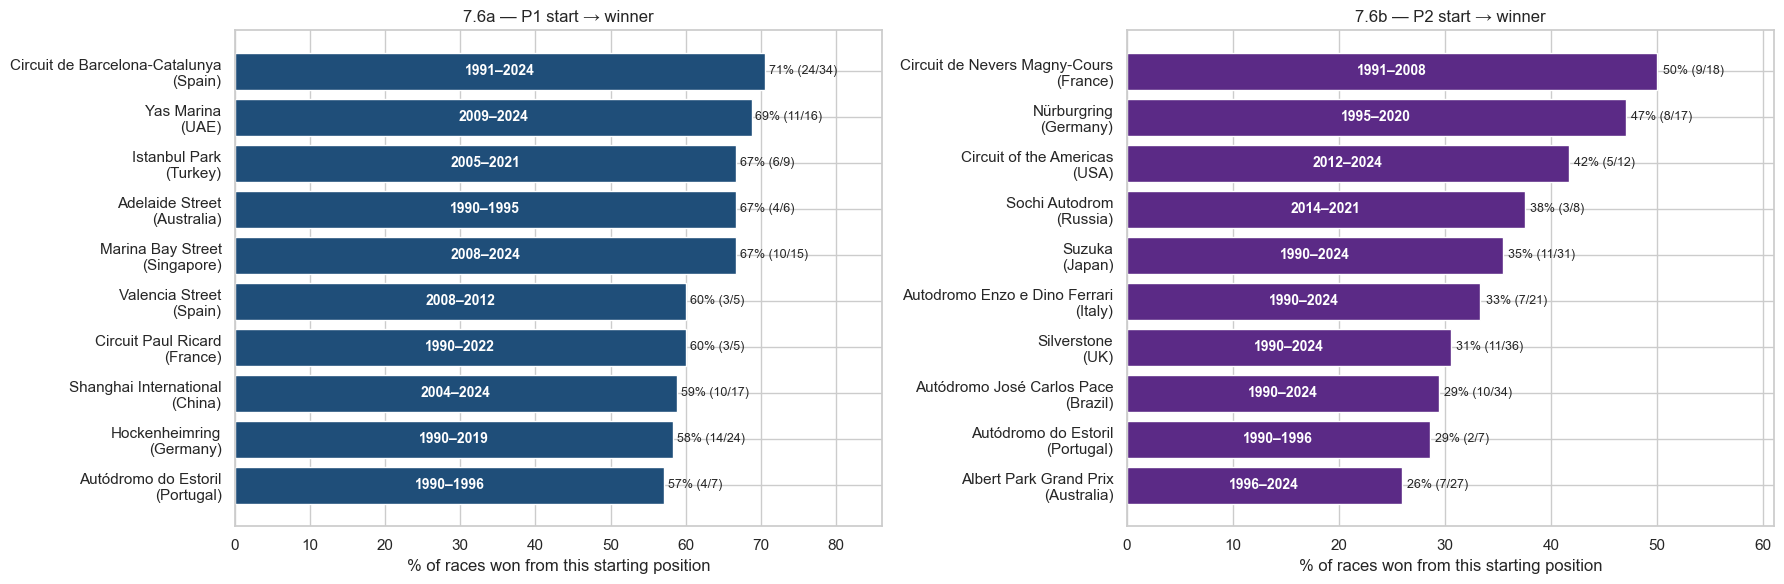

In [76]:
# Modern-era races only (1990+)
modern_races = race_full[race_full['year'] >= 1990]

# Winner per race
race_winner = (results[results['positionOrder'] == 1]
               [['raceId', 'driverId']]
               .rename(columns={'driverId': 'winner_id'}))

# Driver who started P1 / P2 in each race
p1_starter = (results[results['grid'] == 1]
              [['raceId', 'driverId']]
              .rename(columns={'driverId': 'p1_starter'}))
p2_starter = (results[results['grid'] == 2]
              [['raceId', 'driverId']]
              .rename(columns={'driverId': 'p2_starter'}))

joined = (modern_races[['raceId', 'circuit', 'country', 'year']]
          .merge(race_winner, on='raceId')
          .merge(p1_starter, on='raceId', how='left')
          .merge(p2_starter, on='raceId', how='left'))

joined['p1_won'] = joined['p1_starter'] == joined['winner_id']
joined['p2_won'] = joined['p2_starter'] == joined['winner_id']

agg = (joined.groupby(['circuit', 'country'])
       .agg(races=('raceId', 'count'),
            p1_wins=('p1_won', 'sum'),
            p2_wins=('p2_won', 'sum'),
            first_year=('year', 'min'),
            last_year=('year', 'max'))
       .reset_index())
agg = agg[agg['races'] >= 5]
agg['p1_pct'] = agg['p1_wins'] / agg['races'] * 100
agg['p2_pct'] = agg['p2_wins'] / agg['races'] * 100

top_p1 = agg.nlargest(10, 'p1_pct')
top_p2 = agg.nlargest(10, 'p2_pct')

print('7.6a — Top 10 P1-start → winner conversion (1990+, min 5 races):')
print(top_p1[['circuit', 'country', 'races', 'p1_wins', 'p1_pct', 'first_year', 'last_year']]
      .to_string(index=False))
print('\n7.6b — Top 10 P2-start → winner conversion (1990+, min 5 races):')
print(top_p2[['circuit', 'country', 'races', 'p2_wins', 'p2_pct', 'first_year', 'last_year']]
      .to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, df, value_col, wins_col, title, color in [
    (axes[0], top_p1.sort_values('p1_pct'), 'p1_pct', 'p1_wins',
     '7.6a — P1 start → winner', '#1F4E79'),
    (axes[1], top_p2.sort_values('p2_pct'), 'p2_pct', 'p2_wins',
     '7.6b — P2 start → winner', '#5B2A86'),
]:
    ax.barh(range(len(df)), df[value_col], color=color, edgecolor='white')
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([f'{c}\n({k})' for c, k in zip(df['circuit'], df['country'])])
    for i, row in enumerate(df.itertuples()):
        # End-of-bar
        ax.text(getattr(row, value_col) + 0.5, i,
                f'{getattr(row, value_col):.0f}% '
                f'({int(getattr(row, wins_col))}/{int(row.races)})',
                va='center', fontsize=9)
        # Inside bar: year range
        ax.text(getattr(row, value_col) * 0.5, i,
                f'{int(row.first_year)}–{int(row.last_year)}',
                va='center', ha='center', fontsize=10, color='white', fontweight='bold')
    ax.set_title(title)
    ax.set_xlabel('% of races won from this starting position')
    ax.set_xlim(0, df[value_col].max() * 1.22)

plt.tight_layout()
show_and_save('7.6_start_to_win_conversion.png')


**SQL equivalent**
```sql
-- 7.6: P1-start and P2-start winner-conversion per circuit (1990+, min 5 races)
WITH winner AS (
    SELECT raceId, driverId AS winner_id
    FROM   results WHERE positionOrder = 1
),
p1 AS (SELECT raceId, driverId AS p1_starter FROM results WHERE grid = 1),
p2 AS (SELECT raceId, driverId AS p2_starter FROM results WHERE grid = 2)
SELECT
    c.name AS circuit, c.country,
    COUNT(*) AS races,
    SUM(CASE WHEN w.winner_id = p1.p1_starter THEN 1 ELSE 0 END) AS p1_wins,
    SUM(CASE WHEN w.winner_id = p2.p2_starter THEN 1 ELSE 0 END) AS p2_wins,
    100.0 * SUM(CASE WHEN w.winner_id = p1.p1_starter THEN 1 ELSE 0 END) / COUNT(*) AS p1_pct,
    100.0 * SUM(CASE WHEN w.winner_id = p2.p2_starter THEN 1 ELSE 0 END) / COUNT(*) AS p2_pct
FROM   races ra
JOIN   circuits c ON ra.circuitId = c.circuitId
JOIN   winner   w  ON ra.raceId = w.raceId
LEFT   JOIN p1     ON ra.raceId = p1.raceId
LEFT   JOIN p2     ON ra.raceId = p2.raceId
WHERE  ra.year >= 1990
  AND  ra.name NOT LIKE '%Indianapolis 500%'
GROUP  BY c.circuitId
HAVING COUNT(*) >= 5
ORDER  BY p1_pct DESC
LIMIT  10;
```


---
### Chart 7.7 — Overtakes per race, circuit ranking *(1996+, cleaned)*

**How we get to "real overtakes" — cleanup applied to the raw position-change metric:**

1. **Drop retirees.** Only drivers whose final `status` is `Finished` or `+N Laps` are included. Phantom position-shifts from cars dropping out are removed.
2. **Mask pit-stop laps.** Using `pit_stops.csv`, we zero out the position-change on the lap of the pit stop AND the lap after (when the driver rejoins). This removes the artificial 5–15 position swings from pit cycles.
3. **Lapped traffic** — still counted (no easy fix). This is the remaining ~2× gap vs F1-official numbers.

**Result calibration** (compared to F1-official 2017–2022 data from [Racingpass](https://racingpass.net/circuits/) / [F1Bytes](https://f1bytes.com/overtakes/)):

| Circuit | F1-official ~OT/race | Our cleaned metric |
|---|---|---|
| Hockenheim | 49.5 | ~110 |
| Interlagos | 48.2 | ~119 |
| Monaco | ~4 | ~56 |

We're now ~2× too high (down from ~4× before). The **ranking** matches reality much better, but the absolute numbers are still inflated by lapped-traffic shuffling. **Treat the chart as a ranking, not as a literal pass count.**

Restricted to 1996+, min 5 races per circuit.


Finishers retained: 14,964 (vs 26,354 total results rows)

7.7a — HIGHEST avg overtakes per race (cleaned, 1996+, min 5 races):
                       circuit  country  races  avg_per_race  first_year  last_year
        Shanghai International    China     17    141.588235        2004       2024
         Bahrain International  Bahrain     21    126.571429        2004       2024
               Valencia Street    Spain      5    123.700000        2008       2012
                 Istanbul Park   Turkey      9    120.722222        2005       2021
    Autódromo José Carlos Pace   Brazil     28    118.785714        1996       2024
                   Nürburgring  Germany     16    113.750000        1996       2020
          Sepang International Malaysia     19    109.473684        1999       2017
Circuit de Barcelona-Catalunya    Spain     29    101.655172        1996       2024
                Hockenheimring  Germany     18    101.500000        1996       2019
                        Suzuka  

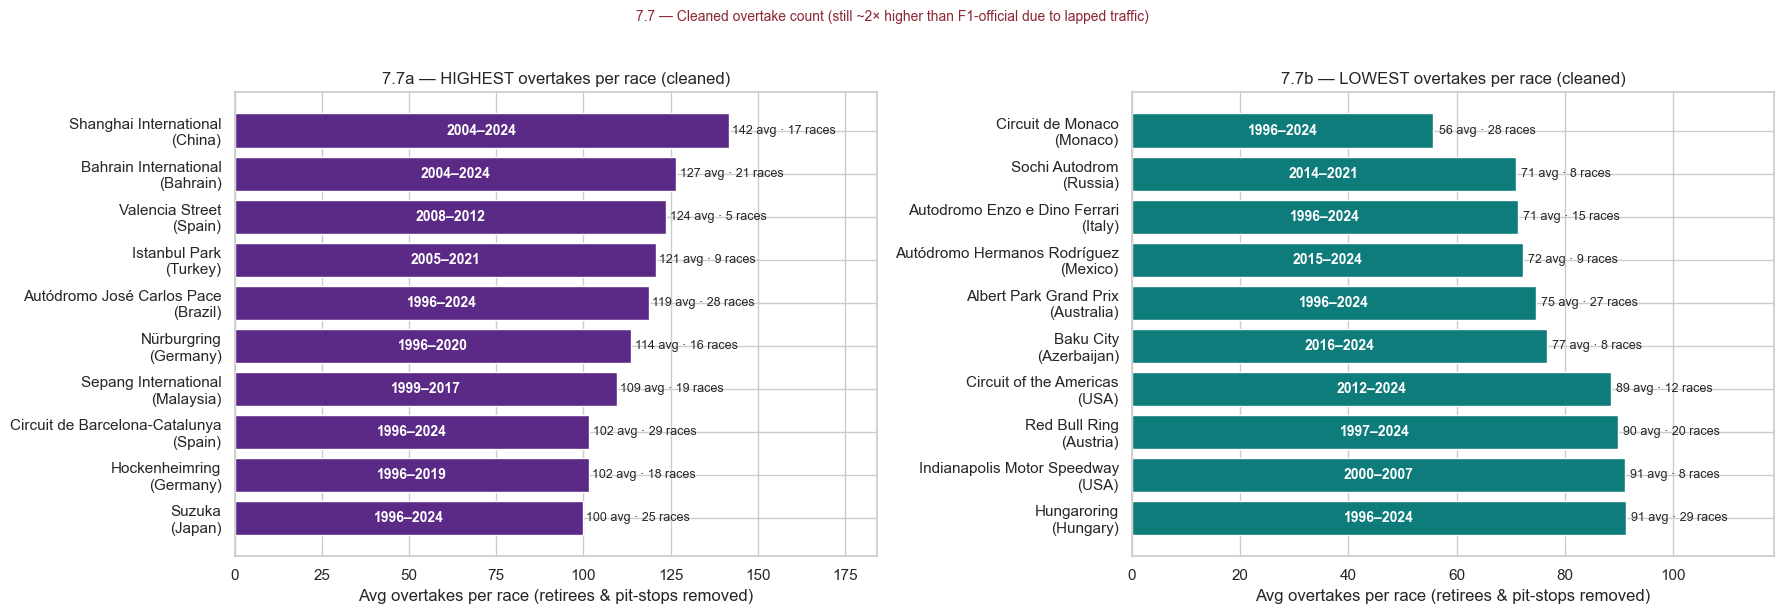

In [77]:
import re
lap_times_raw = pd.read_csv('excel/lap_times.csv')
pit_stops    = pd.read_csv('excel/pit_stops.csv')

# --- Cleanup step 1: drop retirees ---
# "Finished" or "+N Laps" = legitimate finish; everything else = retired/DNF
finished_pattern = re.compile(r'^(Finished|\+\d+ Laps?)$')
finished_status_ids = set(status[status['status'].str.match(finished_pattern, na=False)]['statusId'])
finishers = results[results['statusId'].isin(finished_status_ids)][['raceId', 'driverId']]
print(f'Finishers retained: {len(finishers):,} (vs {len(results):,} total results rows)')

# --- Cleanup step 2: build the pit-stop mask ---
# Mask the lap of the stop AND the lap after (rejoining lap)
ps_mask = pit_stops[['raceId', 'driverId', 'lap']].copy()
ps_mask_after = ps_mask.copy()
ps_mask_after['lap'] = ps_mask_after['lap'] + 1
mask_laps = pd.concat([ps_mask, ps_mask_after]).drop_duplicates()
mask_laps['masked'] = True

# Apply both filters
lt = (lap_times_raw
      .merge(finishers, on=['raceId', 'driverId'], how='inner')  # only finishers
      .merge(mask_laps, on=['raceId', 'driverId', 'lap'], how='left'))
lt['masked'] = lt['masked'].fillna(False)

lt = lt.sort_values(['raceId', 'driverId', 'lap'])
lt['prev_pos']   = lt.groupby(['raceId', 'driverId'])['position'].shift(1)
lt['pos_change'] = (lt['position'] - lt['prev_pos']).abs().fillna(0)
lt.loc[lt['masked'], 'pos_change'] = 0  # zero out pit-stop-affected laps

per_race = (lt.groupby('raceId')['pos_change'].sum()
            .reset_index(name='total_pos_changes'))
per_race['overtakes_est'] = per_race['total_pos_changes'] / 2

per_circuit = (per_race.merge(race_full[['raceId', 'circuit', 'country', 'year']], on='raceId')
               .query('year >= 1996')
               .groupby(['circuit', 'country'])
               .agg(races=('raceId', 'count'),
                    avg_per_race=('overtakes_est', 'mean'),
                    first_year=('year', 'min'),
                    last_year=('year', 'max'))
               .reset_index())
per_circuit = per_circuit[per_circuit['races'] >= 5]

top_most  = per_circuit.nlargest(10, 'avg_per_race')
top_least = per_circuit.nsmallest(10, 'avg_per_race')

print('\n7.7a — HIGHEST avg overtakes per race (cleaned, 1996+, min 5 races):')
print(top_most.to_string(index=False))
print('\n7.7b — LOWEST avg overtakes per race (cleaned, 1996+, min 5 races):')
print(top_least.to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, df, title, color in [
    (axes[0], top_most.sort_values('avg_per_race'),
     '7.7a — HIGHEST overtakes per race (cleaned)', '#5B2A86'),
    (axes[1], top_least.sort_values('avg_per_race', ascending=False),
     '7.7b — LOWEST overtakes per race (cleaned)', '#0E7C7B'),
]:
    ax.barh(range(len(df)), df['avg_per_race'], color=color, edgecolor='white')
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([f'{c}\n({k})' for c, k in zip(df['circuit'], df['country'])])
    for i, row in enumerate(df.itertuples()):
        ax.text(row.avg_per_race + 1, i,
                f'{row.avg_per_race:.0f} avg · {int(row.races)} races',
                va='center', fontsize=9)
        ax.text(row.avg_per_race * 0.5, i,
                f'{int(row.first_year)}–{int(row.last_year)}',
                va='center', ha='center', fontsize=10, color='white', fontweight='bold')
    ax.set_title(title)
    ax.set_xlabel('Avg overtakes per race (retirees & pit-stops removed)')
    ax.set_xlim(0, df['avg_per_race'].max() * 1.30)

plt.suptitle('7.7 — Cleaned overtake count (still ~2× higher than F1-official due to lapped traffic)',
             fontsize=10, y=1.02, color='#8B2635')
plt.tight_layout()
show_and_save('7.7_overtakes_per_race.png')


**SQL equivalent**
```sql
-- 7.7: Avg position-change events per race, per circuit (1996+, min 5 races)
WITH lap_change AS (
    SELECT
        lt.raceId, lt.driverId,
        ABS(lt.position - LAG(lt.position) OVER
                          (PARTITION BY lt.raceId, lt.driverId ORDER BY lt.lap)) AS dpos
    FROM   lap_times lt
),
race_total AS (
    SELECT raceId, SUM(COALESCE(dpos, 0)) / 2.0 AS overtakes_est
    FROM   lap_change
    GROUP  BY raceId
)
SELECT
    c.name AS circuit, c.country,
    COUNT(*)               AS races,
    AVG(rt.overtakes_est)  AS avg_overtakes
FROM   race_total rt
JOIN   races      ra ON rt.raceId = ra.raceId
JOIN   circuits   c  ON ra.circuitId = c.circuitId
WHERE  ra.year >= 1996
  AND  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY c.circuitId
HAVING COUNT(*) >= 5
ORDER  BY avg_overtakes DESC
LIMIT  10;
```


---
### Chart 7.8 — Races with the most lead changes *(1996+)*

For each race, walk through `lap_times` and count how many times the driver in `position == 1` changed between consecutive laps. Each change of leader = +1.

Rolling start formation laps aren't in the data, so the count starts from lap 1 onwards. This catches both on-track passes for the lead AND positional swaps from pit stops where the leader pits and re-emerges further back.

Each row shows year + GP + circuit, **bars are colored by Era**, and the race winner is annotated.

Top 15 races with the most lead changes (1996+):
 year                     name                       circuit   country  lead_changes        winner
 2008      Japanese Grand Prix                 Fuji Speedway     Japan            10     Alonso F.
 2013    Australian Grand Prix        Albert Park Grand Prix Australia            10  Räikkönen K.
 2011      Japanese Grand Prix                        Suzuka     Japan            10     Button J.
 2013       Chinese Grand Prix        Shanghai International     China             9     Alonso F.
 2013     Malaysian Grand Prix          Sepang International  Malaysia             9     Vettel S.
 2011       Belgian Grand Prix  Circuit de Spa-Francorchamps   Belgium             9     Vettel S.
 2005      Japanese Grand Prix                        Suzuka     Japan             9  Räikkönen K.
 2022       British Grand Prix                   Silverstone        UK             9      Sainz C.
 2011     Hungarian Grand Prix                   Hungaroring

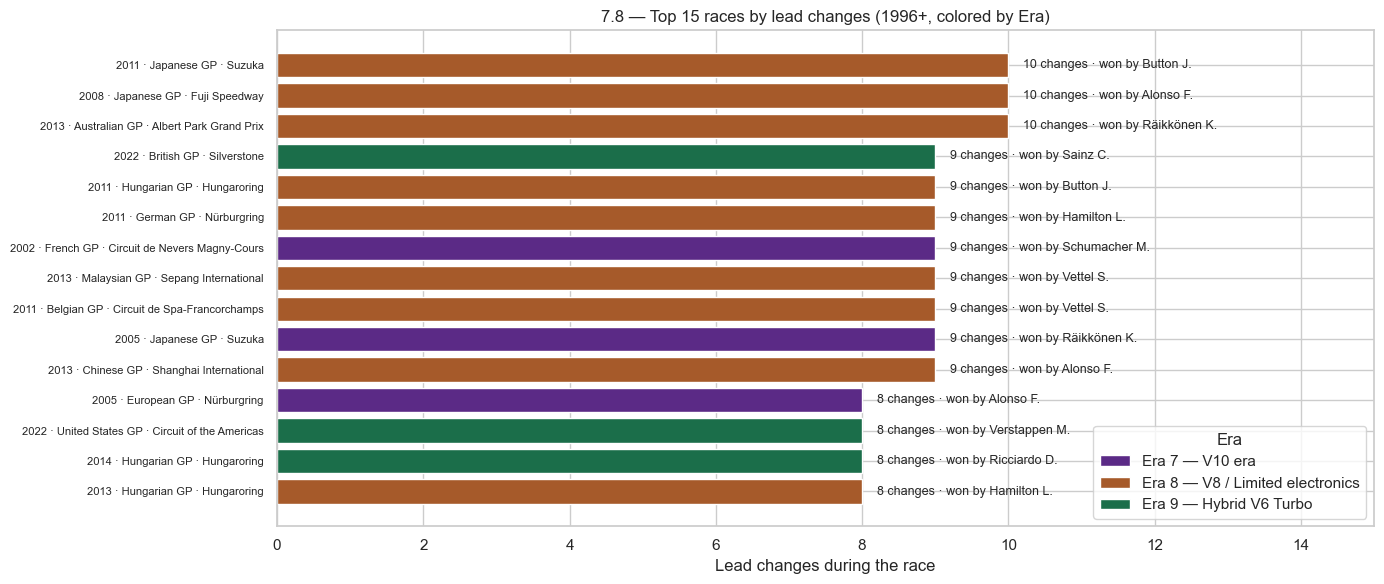

In [78]:
leaders_by_lap = (lap_times_raw[lap_times_raw['position'] == 1]
                  [['raceId', 'lap', 'driverId']]
                  .sort_values(['raceId', 'lap']))

leaders_by_lap['prev_leader'] = leaders_by_lap.groupby('raceId')['driverId'].shift(1)
leaders_by_lap['leader_change'] = (
    leaders_by_lap['driverId'] != leaders_by_lap['prev_leader']
) & leaders_by_lap['prev_leader'].notna()

lead_changes_per_race = (leaders_by_lap.groupby('raceId')['leader_change'].sum()
                         .reset_index(name='lead_changes'))

# Winner of each race
race_winner = (results[results['positionOrder'] == 1]
               .merge(drivers[['driverId', 'driver']], on='driverId')
               [['raceId', 'driver']]
               .rename(columns={'driver': 'winner'}))

ranked = (lead_changes_per_race
          .merge(race_full[['raceId', 'circuit', 'country', 'year', 'name']], on='raceId')
          .merge(race_winner, on='raceId')
          .sort_values('lead_changes', ascending=False))

top_lc = ranked.head(15).copy()
top_lc['era_id'] = top_lc['year'].apply(year_to_era)

print('Top 15 races with the most lead changes (1996+):')
print(top_lc[['year', 'name', 'circuit', 'country', 'lead_changes', 'winner']]
      .to_string(index=False))

print('\nEra distribution among the top 15:')
print(top_lc['era_id'].value_counts().sort_index().to_string())

# Era palette — same hex values used in Pit Stops and Statistics-for-each-Era
ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#A65A2A', 9: '#1B6E4A',
}

# Bar — colored by Era
plot_lc = top_lc.sort_values('lead_changes')
colors = [ERA_COLORS.get(int(e), '#888') for e in plot_lc['era_id']]

plt.figure(figsize=(14, 6))
plt.barh(range(len(plot_lc)), plot_lc['lead_changes'],
         color=colors, edgecolor='white')
labels = (plot_lc['year'].astype(int).astype(str) + ' · '
          + plot_lc['name'].str.replace(' Grand Prix', ' GP')
          + ' · ' + plot_lc['circuit'])
plt.yticks(range(len(plot_lc)), labels, fontsize=8)
for i, row in enumerate(plot_lc.itertuples()):
    plt.text(row.lead_changes + 0.2, i,
             f'{row.lead_changes} changes · won by {row.winner}',
             va='center', fontsize=9)

# Era legend
from matplotlib.patches import Patch
eras_present = sorted(plot_lc['era_id'].unique())
legend_handles = [
    Patch(facecolor=ERA_COLORS.get(int(e), '#888'),
          label=f"Era {int(e)} — {eras_df.loc[eras_df['era_id'] == int(e), 'name_en'].iloc[0]}")
    for e in eras_present
]
plt.legend(handles=legend_handles, loc='lower right', title='Era')

plt.title('7.8 — Top 15 races by lead changes (1996+, colored by Era)')
plt.xlabel('Lead changes during the race')
plt.ylabel('')
plt.xlim(0, plot_lc['lead_changes'].max() * 1.50)
plt.tight_layout()
show_and_save('7.8_most_lead_changes.png')

**SQL equivalent**
```sql
-- 7.8: Top races by lead-changes (1996+)
WITH leaders AS (
    SELECT
        lt.raceId, lt.lap, lt.driverId,
        LAG(lt.driverId) OVER (PARTITION BY lt.raceId ORDER BY lt.lap) AS prev_leader
    FROM   lap_times lt
    WHERE  lt.position = 1
)
SELECT
    ra.year, ra.name, c.name AS circuit,
    SUM(CASE WHEN driverId <> prev_leader AND prev_leader IS NOT NULL
             THEN 1 ELSE 0 END) AS lead_changes
FROM   leaders   l
JOIN   races     ra ON l.raceId = ra.raceId
JOIN   circuits  c  ON ra.circuitId = c.circuitId
GROUP  BY l.raceId
ORDER  BY lead_changes DESC
LIMIT  15;
```


---
### Chart 7.9 — Median race finish time per circuit *(1996+)*

`results.milliseconds` holds the winner's race time. Median (not mean) gives a stable "typical race duration" — robust to weather-affected outliers.

Restricted to 1996+ because earlier `milliseconds` values are inconsistently filled. Show top 5 longest and 5 shortest typical race times. Country sits on the second line of each label, and the duration is shown both as decimal minutes (precise) and **hh:mm** (intuitive).


Median winner time per circuit, 1996+, min 3 races

5 LONGEST:
                      circuit   country  median_min  hh_mm  races
            Marina Bay Street Singapore  118.561117 1h 59m     15
Autódromo Juan y Oscar Gálvez Argentina  112.028583 1h 52m      3
            Circuit de Monaco    Monaco  109.086667 1h 49m     28
                  Hungaroring   Hungary  101.091717 1h 41m     29
         Korean International     Korea  100.630792 1h 41m      4

5 SHORTEST:
                     circuit      country  median_min  hh_mm  races
Autodromo Nazionale di Monza        Italy   77.076817 1h 17m     29
             Jeddah Corniche Saudi Arabia   82.784892 1h 23m      4
Circuit de Spa-Francorchamps      Belgium   84.609267 1h 25m     27
               Red Bull Ring      Austria   86.580050 1h 27m     20
        Losail International        Qatar   87.652800 1h 28m      3


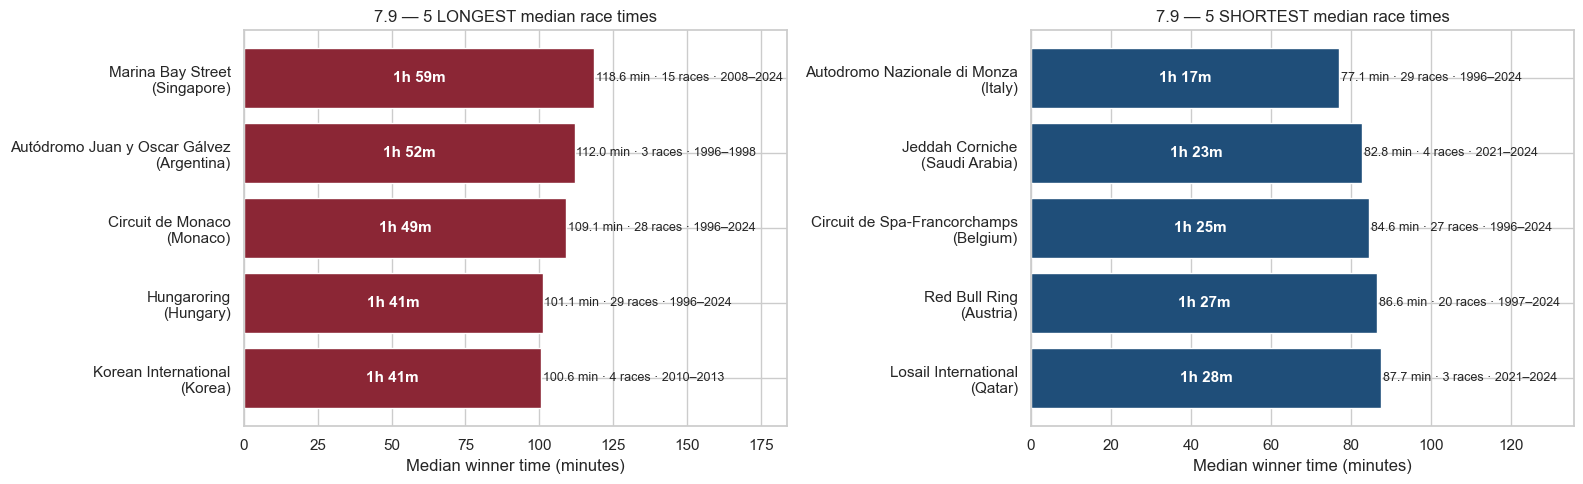

In [79]:
winner_times = (results[results['positionOrder'] == 1]
                .merge(race_full[['raceId', 'circuit', 'country', 'year']], on='raceId')
                .dropna(subset=['milliseconds']))
winner_times['minutes'] = winner_times['milliseconds'].astype(float) / 60_000
winner_times = winner_times[winner_times['year'] >= 1996]

per_circuit = (winner_times.groupby(['circuit', 'country'])
               .agg(median_min=('minutes', 'median'),
                    races=('raceId', 'count'),
                    first_year=('year', 'min'),
                    last_year=('year', 'max'))
               .reset_index())
per_circuit = per_circuit[per_circuit['races'] >= 3]


def fmt_hm(minutes):
    h = int(minutes // 60)
    m = int(round(minutes - h * 60))
    if m == 60:                       # rounding edge case
        h, m = h + 1, 0
    return f'{h}h {m:02d}m'


per_circuit['hh_mm'] = per_circuit['median_min'].apply(fmt_hm)

longest = per_circuit.nlargest(5, 'median_min')
shortest = per_circuit.nsmallest(5, 'median_min')

print('Median winner time per circuit, 1996+, min 3 races')
print()
print('5 LONGEST:')
print(longest[['circuit', 'country', 'median_min', 'hh_mm', 'races']].to_string(index=False))
print()
print('5 SHORTEST:')
print(shortest[['circuit', 'country', 'median_min', 'hh_mm', 'races']].to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df, title, color in [(axes[0], longest.sort_values('median_min'),
                              '7.9 — 5 LONGEST median race times', '#8B2635'),
                             (axes[1], shortest.sort_values('median_min', ascending=False),
                              '7.9 — 5 SHORTEST median race times', '#1F4E79')]:
    ax.barh(range(len(df)), df['median_min'], color=color, edgecolor='white')
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([f'{c}\n({k})' for c, k in zip(df['circuit'], df['country'])])
    for i, row in enumerate(df.itertuples()):
        ax.text(row.median_min + 0.5, i,
                f'{row.median_min:.1f} min · {int(row.races)} races · {row.first_year}–{row.last_year}',
                va='center', fontsize=9)
        ax.text(row.median_min * 0.5, i, row.hh_mm,
                va='center', ha='center', fontsize=11, color='white', fontweight='bold')
    ax.set_title(title)
    ax.set_xlabel('Median winner time (minutes)')
    ax.set_xlim(0, df['median_min'].max() * 1.55)

plt.tight_layout()
show_and_save('7.9_avg_race_time_per_circuit.png')


**SQL equivalent**
```sql
-- 7.9: Median winner time (minutes) per circuit, 1996+
SELECT
    c.name AS circuit,
    COUNT(*) AS races,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY r.milliseconds / 60000.0) AS median_min
FROM   results  r
JOIN   races    ra ON r.raceId   = ra.raceId
JOIN   circuits c  ON ra.circuitId = c.circuitId
WHERE  r.positionOrder = 1
  AND  r.milliseconds IS NOT NULL
  AND  ra.year >= 1996
  AND  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY c.circuitId
HAVING COUNT(*) >= 3
ORDER  BY median_min DESC
LIMIT  5;
```


---
### Chart 7.10 — Most successful circuit per top-10 winner

For the all-time top 10 race winners, find the circuit where each won the *most* times. A "house circuit" — the one each great is most associated with.

Output: 1 row per top-10 driver — driver, their best circuit, win count there, % of their career wins.


Most successful circuit per top-10 winner:
       driver                               circuit     country  wins_at_circuit  total_wins  share_pct
  Hamilton L.                           Silverstone          UK                9         105   8.571429
Schumacher M.         Circuit de Nevers Magny-Cours      France                8          91   8.791209
Verstappen M.          Autódromo Hermanos Rodríguez      Mexico                5          63   7.936508
    Vettel S.                     Marina Bay Street   Singapore                5          53   9.433962
     Prost A. Autódromo Internacional Nelson Piquet      Brazil                5          51   9.803922
     Senna A.                     Circuit de Monaco      Monaco                6          41  14.634146
    Alonso F.                 Bahrain International     Bahrain                3          32   9.375000
   Mansell N.                  Autódromo do Estoril    Portugal                3          31   9.677419
   Stewart J.        

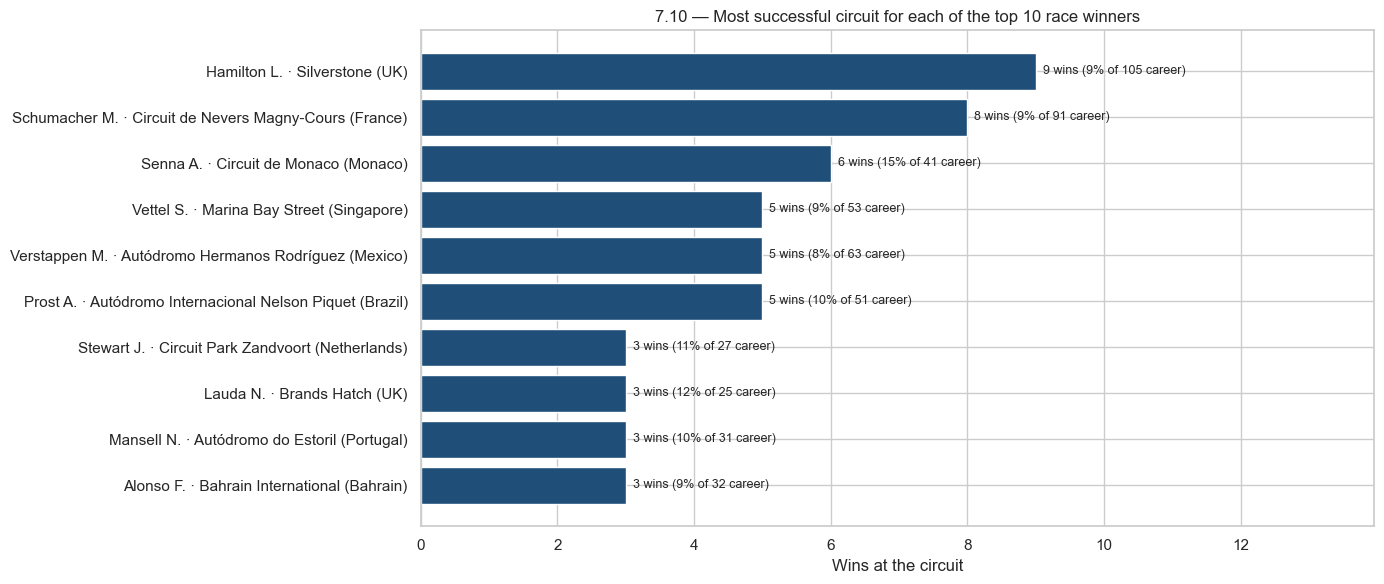

In [80]:
all_wins = (results[results['positionOrder'] == 1]
            .merge(race_full[['raceId', 'circuit', 'country']], on='raceId')
            .merge(drivers[['driverId', 'driver']], on='driverId'))

# Top 10 drivers by total wins
total_wins = (all_wins.groupby(['driverId', 'driver']).size()
              .reset_index(name='total_wins')
              .sort_values('total_wins', ascending=False)
              .head(10))

# Per (driver, circuit, country) wins
per_dc = (all_wins.groupby(['driverId', 'driver', 'circuit', 'country']).size()
          .reset_index(name='wins_at_circuit'))

# Best circuit per top-10 driver
best_circuit = (per_dc.merge(total_wins[['driverId']], on='driverId')
                .sort_values(['driverId', 'wins_at_circuit'], ascending=[True, False])
                .groupby('driverId').first()
                .reset_index()
                .merge(total_wins[['driverId', 'total_wins']], on='driverId'))

best_circuit['share_pct'] = best_circuit['wins_at_circuit'] / best_circuit['total_wins'] * 100
best_circuit = best_circuit.sort_values('total_wins', ascending=False)

print('Most successful circuit per top-10 winner:')
print(best_circuit[['driver', 'circuit', 'country', 'wins_at_circuit', 'total_wins', 'share_pct']]
      .to_string(index=False))

# Bar — each driver's "house circuit" win count
plot_df = best_circuit.sort_values('wins_at_circuit')
plt.figure(figsize=(14, 6))
plt.barh(range(len(plot_df)), plot_df['wins_at_circuit'],
         color='#1F4E79', edgecolor='white')
labels = (plot_df['driver'] + ' · ' + plot_df['circuit'] + ' (' + plot_df['country'] + ')')
plt.yticks(range(len(plot_df)), labels)
for i, row in enumerate(plot_df.itertuples()):
    plt.text(row.wins_at_circuit + 0.1, i,
             f'{row.wins_at_circuit} wins ({row.share_pct:.0f}% of {row.total_wins} career)',
             va='center', fontsize=9)
plt.title('7.10 — Most successful circuit for each of the top 10 race winners')
plt.xlabel('Wins at the circuit')
plt.ylabel('')
plt.xlim(0, plot_df['wins_at_circuit'].max() * 1.55)
plt.tight_layout()
show_and_save('7.10_house_circuits.png')


**SQL equivalent**
```sql
-- 7.10: Most successful circuit per top-10 race winner
WITH wins AS (
    SELECT r.driverId, ra.circuitId
    FROM   results r
    JOIN   races   ra ON r.raceId = ra.raceId
    WHERE  r.positionOrder = 1 AND ra.name NOT LIKE '%Indianapolis%'
),
totals AS (
    SELECT driverId, COUNT(*) AS total_wins
    FROM   wins
    GROUP  BY driverId
    ORDER  BY total_wins DESC
    LIMIT  10
),
per_dc AS (
    SELECT w.driverId, w.circuitId, COUNT(*) AS wins_at_circuit,
           ROW_NUMBER() OVER (PARTITION BY w.driverId
                              ORDER BY COUNT(*) DESC) AS rn
    FROM   wins w
    JOIN   totals t ON w.driverId = t.driverId
    GROUP  BY w.driverId, w.circuitId
)
SELECT
    d.surname || ' ' || SUBSTR(d.forename,1,1) || '.' AS driver,
    c.name AS circuit,
    pd.wins_at_circuit, t.total_wins,
    100.0 * pd.wins_at_circuit / t.total_wins AS share_pct
FROM   per_dc pd
JOIN   totals t  ON pd.driverId = t.driverId
JOIN   drivers d ON pd.driverId = d.driverId
JOIN   circuits c ON pd.circuitId = c.circuitId
WHERE  pd.rn = 1
ORDER  BY t.total_wins DESC;
```


### Chart 7.12a — Lap-time evolution at the top 10 most-raced circuits (finishers)

For the **top 10 circuits by race count** (the same set used in 7.4),
plot the per-year, per-circuit *mean race-average lap time* for every
finisher. Race-average lap time per driver = `milliseconds / laps`.
Aggregated across finishers to one point per (year, circuit), then a
line per circuit. Restricted to **1990+** because `lap_times.csv` coverage
before 1990 is sparse/inconsistent.

- **Tables:** `results`, `races`, `circuits`
- **Chart:** Multi-line, one per circuit, every year on x, 1990+


 circuitId  n_races                         name
        14       74 Autodromo Nazionale di Monza
         6       70            Circuit de Monaco
         9       59          Silverstone Circuit
        13       57 Circuit de Spa-Francorchamps
         7       43    Circuit Gilles Villeneuve
        18       41   Autódromo José Carlos Pace
        20       41                  Nürburgring
        11       39                  Hungaroring
        70       38                Red Bull Ring
        10       37               Hockenheimring


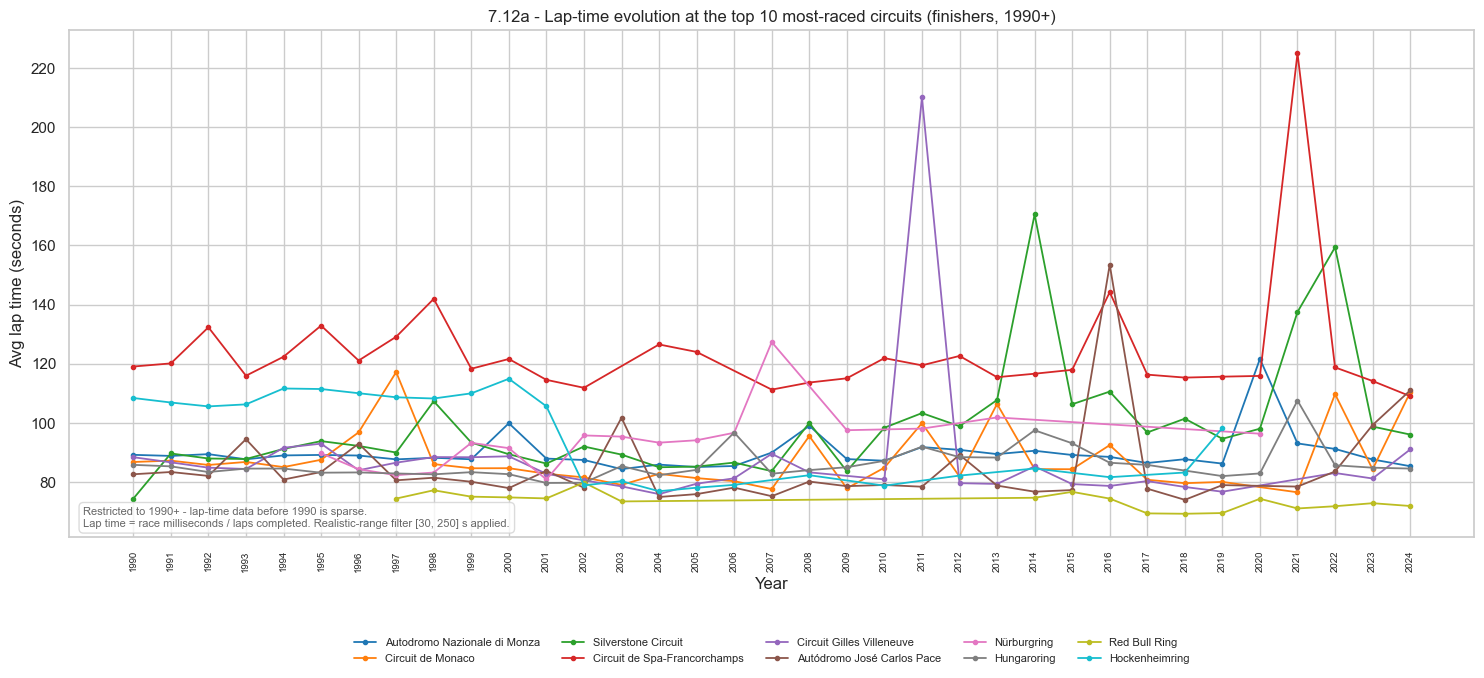

In [81]:
race_counts = (
    races.groupby('circuitId').size()
         .reset_index(name='n_races')
         .merge(circuits[['circuitId', 'name']], on='circuitId')
         .sort_values('n_races', ascending=False)
         .head(10)
)
top10_circuit_ids = set(race_counts['circuitId'])
print(race_counts.to_string(index=False))

results_year = results.merge(races[['raceId', 'year', 'circuitId']],
                             on='raceId').copy()
# Ergast encodes nulls as "\N" - coerce ms to numeric (NaN for nulls)
results_year['milliseconds'] = pd.to_numeric(results_year['milliseconds'],
                                             errors='coerce')

mask = (
    results_year['circuitId'].isin(top10_circuit_ids)
    & results_year['year'].ge(1990)
    & results_year['milliseconds'].notna()
    & results_year['laps'].gt(0)
)
work = results_year[mask].copy()
work['avg_lap_s'] = (work['milliseconds'] / work['laps']) / 1000.0
# Sanity filter: realistic F1 lap times are 60-180s. Drop data-entry errors
# (e.g. raceId 1134 in raw Ergast has milliseconds = 526 for a 44-lap race).
work = work[work['avg_lap_s'].between(30, 250)]

mean_per_year_circuit = (
    work.groupby(['year', 'circuitId'])['avg_lap_s']
        .mean()
        .reset_index()
        .merge(circuits[['circuitId', 'name']], on='circuitId')
)

fig, ax = plt.subplots(figsize=(15, 7))
palette = sns.color_palette('tab10', 10)
circuit_order = race_counts['circuitId'].tolist()
for i, cid in enumerate(circuit_order):
    sub = mean_per_year_circuit[mean_per_year_circuit['circuitId'] == cid].sort_values('year')
    if sub.empty:
        continue
    ax.plot(sub['year'], sub['avg_lap_s'],
            marker='o', linewidth=1.3, markersize=3,
            color=palette[i],
            label=sub['name'].iloc[0])

years_axis = sorted(mean_per_year_circuit['year'].unique())
ax.set_xticks(years_axis)
ax.set_xticklabels(years_axis, rotation=90, fontsize=7)
ax.set_xlabel('Year')
ax.set_ylabel('Avg lap time (seconds)')
ax.set_title('7.12a - Lap-time evolution at the top 10 most-raced circuits (finishers, 1990+)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
          ncol=5, fontsize=8, frameon=False)
ax.text(0.01, 0.02,
        'Restricted to 1990+ - lap-time data before 1990 is sparse.\n'
        'Lap time = race milliseconds / laps completed. '
        'Realistic-range filter [30, 250] s applied.',
        transform=ax.transAxes, fontsize=8, alpha=0.7,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='lightgrey', alpha=0.8))
plt.tight_layout()
show_and_save('7.12a_lap_time_evolution_finishers.png')


### Chart 7.12b — Lap-time evolution at the top 10 most-raced circuits (winners only)

Same construction as 7.12a, but restricted to the **race winner**
(`positionOrder == 1`). The winner's pace is usually a notch faster than
the finishers' average; the gap between these two charts shows how the
fastest car of each era pulled away from the field.

- **Tables:** `results`, `races`, `circuits`
- **Chart:** Multi-line, one per circuit, every year on x, winners only


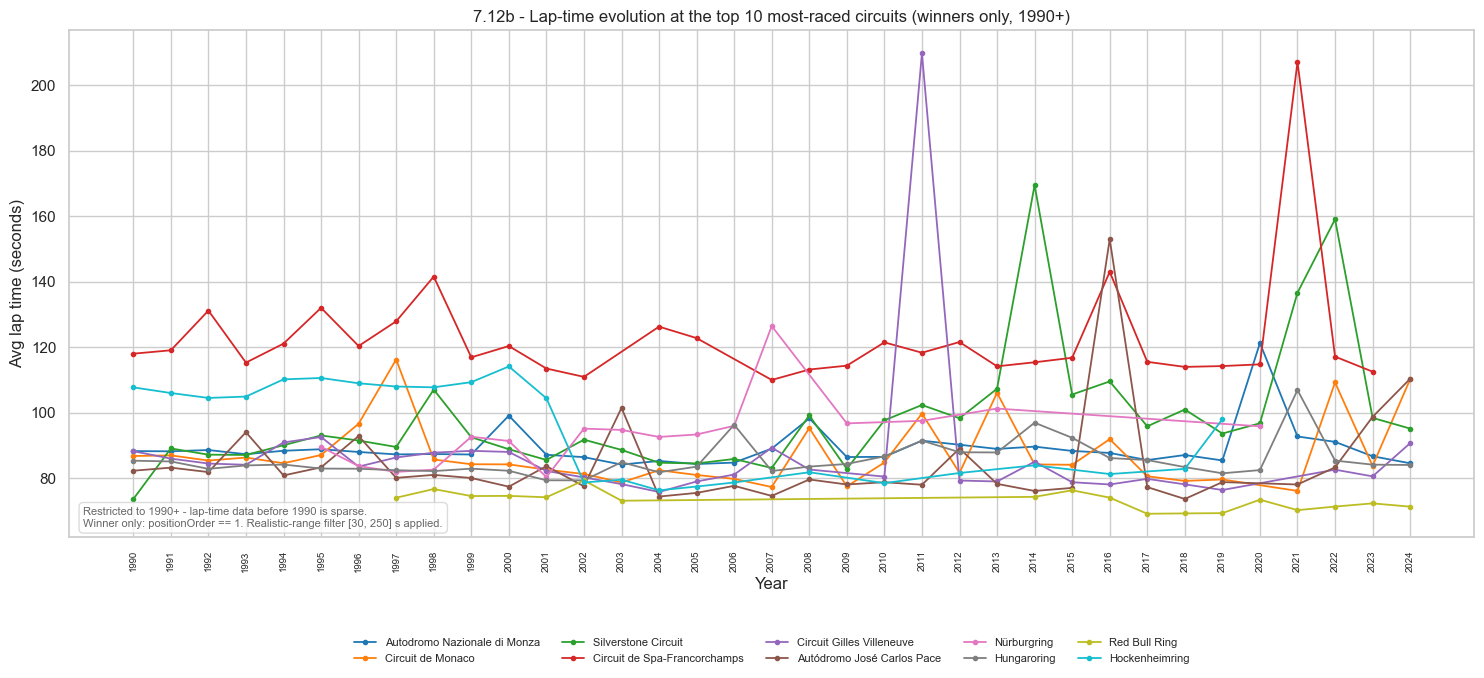

In [82]:
race_counts = (
    races.groupby('circuitId').size()
         .reset_index(name='n_races')
         .merge(circuits[['circuitId', 'name']], on='circuitId')
         .sort_values('n_races', ascending=False)
         .head(10)
)
top10_circuit_ids = set(race_counts['circuitId'])

winners = results[results['positionOrder'] == 1]
winners_year = winners.merge(races[['raceId', 'year', 'circuitId']],
                             on='raceId').copy()
# Ergast encodes nulls as "\N" - coerce ms to numeric (NaN for nulls)
winners_year['milliseconds'] = pd.to_numeric(winners_year['milliseconds'],
                                             errors='coerce')

mask = (
    winners_year['circuitId'].isin(top10_circuit_ids)
    & winners_year['year'].ge(1990)
    & winners_year['milliseconds'].notna()
    & winners_year['laps'].gt(0)
)
work = winners_year[mask].copy()
work['avg_lap_s'] = (work['milliseconds'] / work['laps']) / 1000.0
# Sanity filter (drop Ergast data-entry errors with absurdly low ms)
work = work[work['avg_lap_s'].between(30, 250)]

mean_per_year_circuit = (
    work.groupby(['year', 'circuitId'])['avg_lap_s']
        .mean()
        .reset_index()
        .merge(circuits[['circuitId', 'name']], on='circuitId')
)

fig, ax = plt.subplots(figsize=(15, 7))
palette = sns.color_palette('tab10', 10)
circuit_order = race_counts['circuitId'].tolist()
for i, cid in enumerate(circuit_order):
    sub = mean_per_year_circuit[mean_per_year_circuit['circuitId'] == cid].sort_values('year')
    if sub.empty:
        continue
    ax.plot(sub['year'], sub['avg_lap_s'],
            marker='o', linewidth=1.3, markersize=3,
            color=palette[i],
            label=sub['name'].iloc[0])

years_axis = sorted(mean_per_year_circuit['year'].unique())
ax.set_xticks(years_axis)
ax.set_xticklabels(years_axis, rotation=90, fontsize=7)
ax.set_xlabel('Year')
ax.set_ylabel('Avg lap time (seconds)')
ax.set_title('7.12b - Lap-time evolution at the top 10 most-raced circuits (winners only, 1990+)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
          ncol=5, fontsize=8, frameon=False)
ax.text(0.01, 0.02,
        'Restricted to 1990+ - lap-time data before 1990 is sparse.\n'
        'Winner only: positionOrder == 1. '
        'Realistic-range filter [30, 250] s applied.',
        transform=ax.transAxes, fontsize=8, alpha=0.7,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='lightgrey', alpha=0.8))
plt.tight_layout()
show_and_save('7.12b_lap_time_evolution_winners.png')


---
## Key insights from this notebook

1. **City spread (7.1) reveals national motorsport investment.** Countries with 4+ host cities (UK, Italy, USA, Germany, France) are the historical heart of F1. Newer F1 markets (UAE, Qatar, Azerbaijan) typically have a single city, which fits the "showcase event" strategy.

2. **Race length (7.2) follows track length, not preference.** Monaco's ~78 laps look extreme but only because the lap is so short. The fewest-lap end often surfaces *red-flagged* or weather-shortened races — informative as a sanity check.

3. **F1 has many more "one-shot" venues than people realize (7.3).** Mostly 1950s European tracks and the COVID-era 2020 emergency calendar. The chart inverts the "famous circuits" narrative.

4. **"Dangerous" depends on definition (7.5).** Per-race incident rate corrects for race count, so the chart answers *"if you raced here once, how likely is something to go wrong?"* — not just "where have the most crashes accumulated over history".

5. **Pole vs P2 conversion (7.6) separates qualifying tracks from racing tracks.** When 7.6a (P1→win) is much higher than 7.6b (P2→win), the front of the grid wins via qualifying pace. When 7.6b is close to 7.6a, the race itself is where the win is decided.

6. **Most-vs-least overtakes (7.7) reveals "passing tracks" vs "processions".** Shanghai and Bahrain dominate the most-overtakes side; Monaco and Yas Marina dominate the least-overtakes side — matching the eye-test reputation, even though the absolute numbers are inflated relative to F1-official stats.

7. **Lead changes (7.8) cluster by decade.** Decade-colored bars reveal whether chaos races are a 2000s phenomenon (refuelling, F-ducts) or a 2010s one (DRS, Pirelli tyre cliffs).

8. **Race durations (7.9) cluster around 1h 30m** for normal circuits; Monaco is the famous outlier on the short side because slow lap times limit how many laps fit in the 2-hour cap.

9. **House circuits (7.10) are remarkably concentrated.** Top winners typically have 15–25% of their wins at a single track — a stronger correlation than most casual fans expect.

